In [43]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split

In [44]:
df=pd.read_csv("loan_approval_data.csv")

In [45]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# Handling Missing values

In [48]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [49]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [50]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [51]:
from sklearn.impute import SimpleImputer

In [52]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [53]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [54]:

df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [55]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# EDA

Text(0.5, 1.0, 'Is Loan approved or not?')

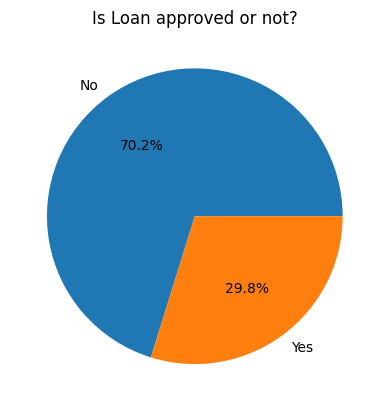

In [57]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

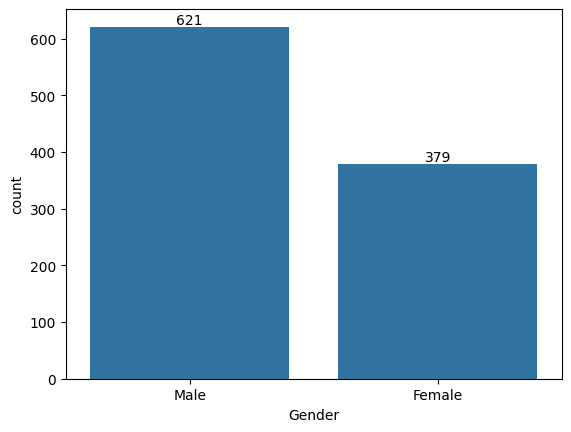

In [58]:
# analyze categories

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])



[Text(0, 0, '722'), Text(0, 0, '278')]

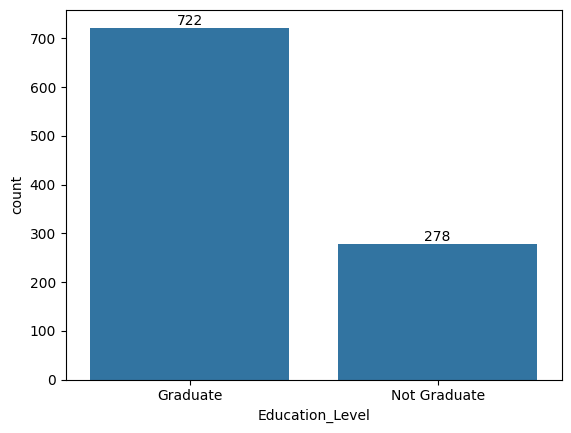

In [59]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

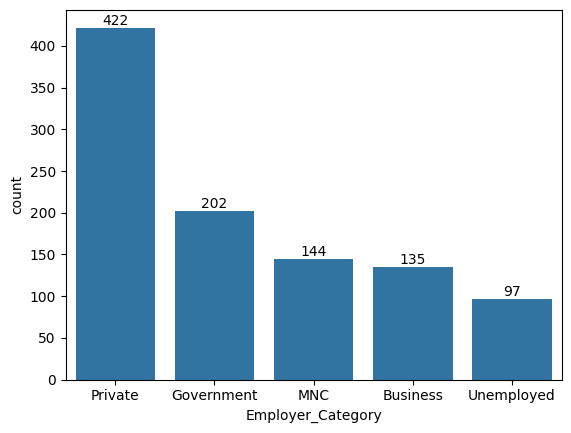

In [60]:

emp_cnt = df["Employer_Category"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

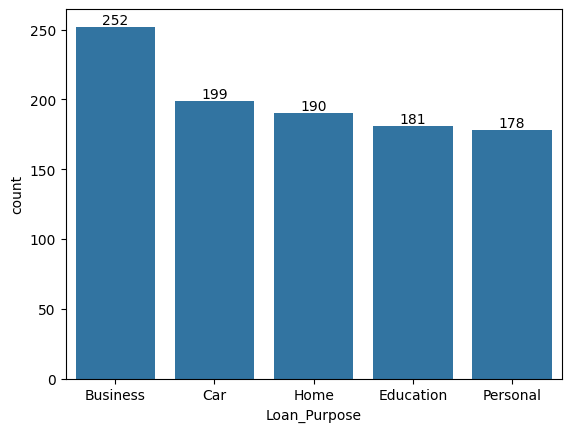

In [61]:

purpose_cnt = df["Loan_Purpose"].value_counts()
ax = sns.barplot(purpose_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

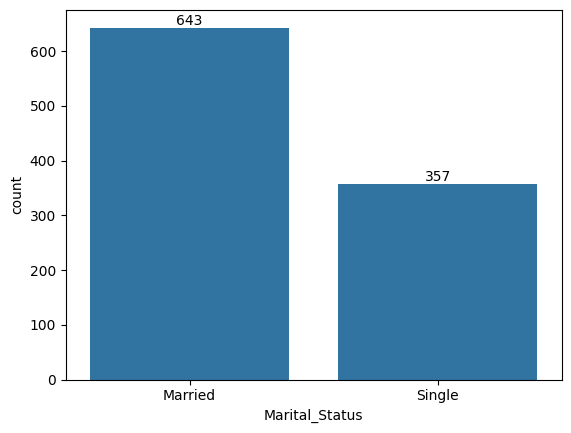

In [62]:
status_cnt = df["Marital_Status"].value_counts()
ax = sns.barplot(status_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

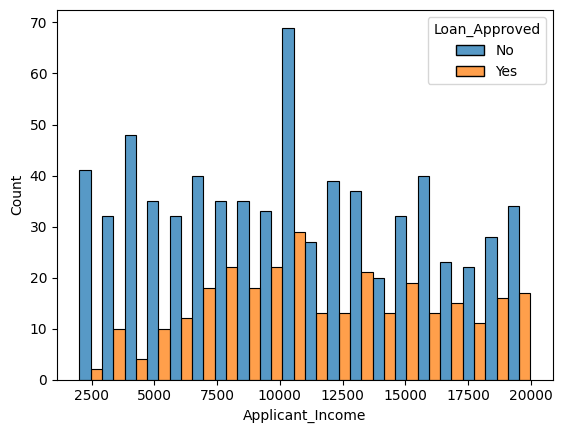

In [63]:
# analyze numerical col

sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

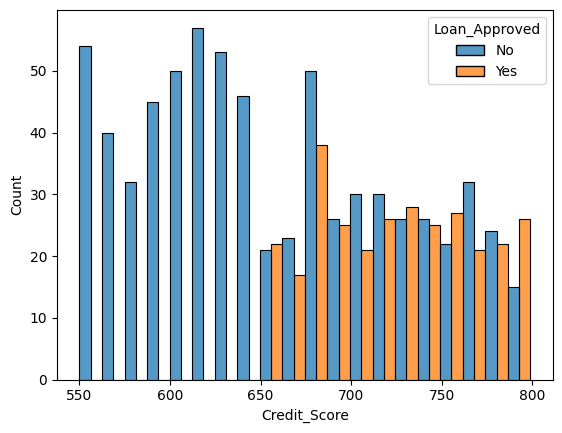

In [64]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Savings', ylabel='Count'>

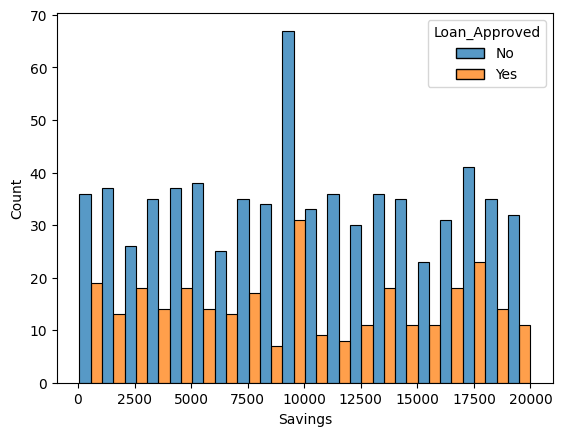

In [65]:
sns.histplot(
    data=df,
    x="Savings",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

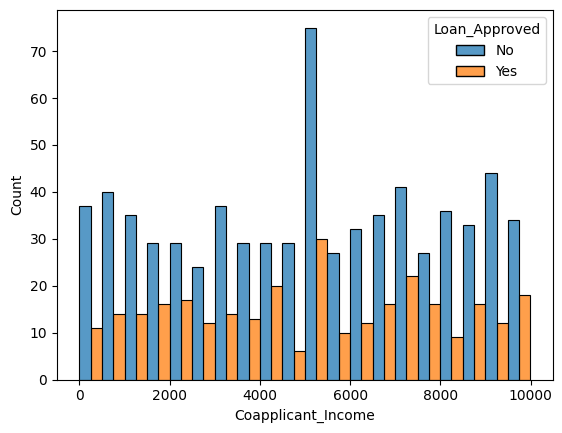

In [66]:

sns.histplot(
    data=df,
    x="Coapplicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

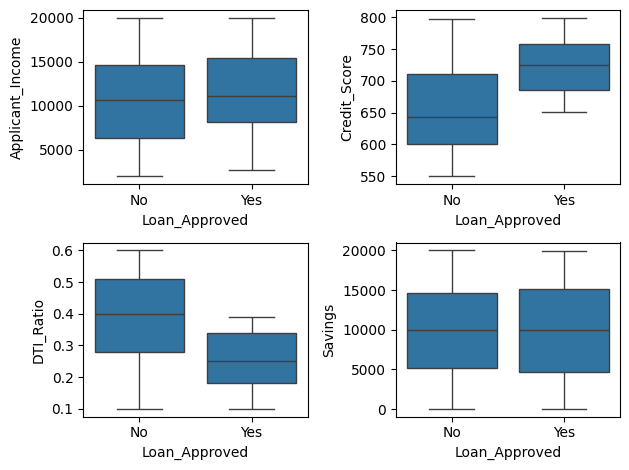

In [67]:
fig, axes = plt.subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved",y="Savings")

plt.tight_layout()

In [68]:
# Remove Applicant Id
df = df.drop("Applicant_ID", axis=1)

In [69]:
df.head(10)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.000000,Salaried,51.0,Married,0.0,637.0,4.0,0.530000,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.000000,Salaried,46.0,Married,3.0,621.0,2.0,0.300000,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.000000,Salaried,25.0,Single,2.0,674.0,4.0,0.200000,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.000000,Salaried,40.0,Married,2.0,579.0,3.0,0.310000,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.000000,Self-employed,31.0,Single,2.0,721.0,1.0,0.290000,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
5,8265.0,4831.000000,Salaried,53.0,Single,1.0,602.0,1.0,0.560000,19522.0,2911.0,9798.0,36.0,Home,Semiurban,Graduate,Male,Unemployed,No
6,18850.0,2768.000000,Salaried,58.0,Married,0.0,687.0,0.0,0.480000,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
7,6426.0,3186.000000,Salaried,47.0,Married,2.0,636.0,4.0,0.347263,671.0,11572.0,33747.0,84.0,Personal,Rural,Graduate,Female,Private,No
8,16423.0,5082.455789,Salaried,54.0,Married,1.0,729.0,0.0,0.590000,777.0,43066.0,34651.0,36.0,Home,Semiurban,Graduate,Male,Private,No
9,13363.0,2599.000000,Contract,35.0,Single,3.0,726.0,1.0,0.347263,3022.0,29693.0,22182.0,60.0,Personal,Rural,Graduate,Female,Government,Yes


# Encoding

In [71]:
from sklearn.preprocessing import LabelEncoder

In [72]:


for col in ["Education_Level", "Employer_Category", "Loan_Approved"]:
    df[col] = LabelEncoder().fit_transform(df[col])

df = pd.get_dummies(df, columns=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender"], drop_first=True,dtype=int)



In [73]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0,0,0,0,0,0,1,0,1,0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0,0,0,1,0,0,0,1,0,1
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0,0,1,0,0,0,0,0,1,0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0,0,0,0,0,0,0,0,0,0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1,0,1,1,0,0,0,0,1,1


In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X=df.drop(columns=["Loan_Approved"])
Y=df["Loan_Approved"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
scaler=StandardScaler()
scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [117]:
X_train_scaled[:5]


array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01,
        -1.36352049e+00, -1.03260224e+00, -1.43086955e+00,
        -1.70971728e+00,  3.42519997e-01, -1.19322630e+00,
         7.91712160e-01, -1.50560555e+00,  1.62879343e+00,
        -9.04600184e-01,  9.65591606e-01, -4.82354268e-01,
        -3.12079621e-01, -7.15742506e-01,  2.07316503e+00,
        -4.80384461e-01, -4.88252079e-01, -4.64548675e-01,
        -4.80384461e-01, -1.05395348e+00, -1.29444401e+00],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01,
        -1.36352049e+00, -8.73568943e-01, -1.43086955e+00,
        -9.92566263e-01, -8.04456237e-01, -1.38581720e+00,
        -5.06017753e-01,  1.02482395e+00,  1.62879343e+00,
        -1.71590080e+00,  9.65591606e-01, -4.82354268e-01,
        -3.12079621e-01, -7.15742506e-01, -4.82354268e-01,
        -4.80384461e-01,  2.04812236e+00, -4.64548675e-01,
        -4.80384461e-01,  9.48808479e-01,  7.72532451e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e